### Chatbot Reading Existing Memories

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [2]:
# ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Ritik"})
store.put(user_details, "profile_2", {"data": "Profession: AI Professional"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [3]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Ritik...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""


In [4]:
# ----------------------------
# 3) Build graph: START -> chat -> END (read-only LTM)
# ----------------------------
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}


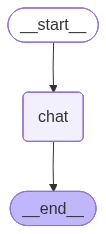

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [7]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)


Sure, Ritik! Generative AI, or gen AI, refers to a type of artificial intelligence that can create content, such as text, images, music, or even code, based on the data it has been trained on. Think of it as a smart creative assistant that learns from existing examples and then generates new, similar ones.

For instance, if you provide inputs like a few sentences or keywords, generative AI can produce paragraphs of text that are coherent and contextually relevant. It's like having a tool that can help you brainstorm ideas or draft documents based on a seed concept. 

Would you like to dive into any specific applications of generative AI or perhaps how it can benefit your Python-based projects? Here are a few questions you might consider:

1. Are you interested in how to integrate generative AI into your MCP server project?
2. Would you like examples of using generative AI libraries in Python?
3. Do you want to explore the ethical implications of generative AI in your field?


### Chatbot Creating New Memories

In [8]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [9]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [10]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [11]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [12]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [13]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

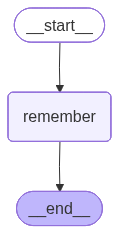

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [15]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Ritik"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [16]:
res = graph.invoke({"messages": [{"role": "user", "content": "I am an AI professional"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [17]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [18]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Ritik.
User is an AI professional.
User's favorite programming language is Python.


### Chatbot Creating New Memories(without Duplication)

In [19]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [20]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [21]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [22]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [23]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [24]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [25]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [26]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [27]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [28]:
config = {"configurable": {"user_id": "u1"}}

In [29]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Ritik"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [30]:
# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [31]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

The user's name is Ritik.
Ritik likes Python for programming.


### Merged Workflow

In [32]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [33]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [34]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure,Ritik...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [35]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [36]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

In [37]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [38]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [39]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [40]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [41]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [42]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

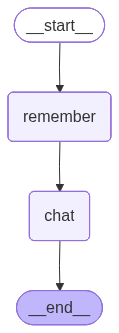

In [43]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [44]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [45]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Ritik"}]}, config)
result['messages'][-1].content

'Hi Ritik! It’s great to meet you! How can I assist you today?'

In [46]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Ritik.


In [47]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am a working professional"}]}, config)
print(result['messages'][-1].content)

Great to know that, Ritik! As a working professional, is there anything specific you'd like assistance with? Whether it's productivity tips, tools you might be using, or even work-life balance advice, I'm here to help! 

What projects are you currently working on?


In [48]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Ritik.


In [49]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Sure, Ritik! GenAI, or Generative AI, refers to a type of artificial intelligence that can create new content, such as text, images, music, or even code, by learning patterns from existing data. Unlike traditional AI, which might classify or analyze data, Generative AI can produce original outputs that mimic the style or structure of the input it was trained on.

For example, if you feed a Generative AI model with a large number of stories, it can generate new stories that have similar themes and styles. It works using advanced algorithms like neural networks, particularly a subset called generative adversarial networks (GANs) or transformer models.

Let me know if you'd like more details on how it works or its applications! 

Here are a few questions you might find interesting:
1. Are you interested in any specific applications of Generative AI, like writing or art?
2. Do you have a particular project in mind where you'd want to use GenAI?
3. Would you like to learn about tools or tec

In [50]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

User's name is Ritik.
